# O2O优惠券精准营销策略分析

基于前期探索性数据分析、特征工程和优惠券核销预测结果，进一步从用户筛选、优惠券设计和营销触达范围等角度进行综合分析，将数据分析与模型结果转化为可执行的精准营销策略。

## 1. 数据准备

读取模型验证集及高潜用户预测结果，为后续用户分层、优惠券策略和营销触达分析提供数据基础。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 路径设置
DATA_DIR = Path("../data/processed")
TABLE_DIR = Path("../output/tables")
FIGURE_DIR = Path("../output/figures")

# 中文显示
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读取验证集
valid_model = pd.read_parquet(DATA_DIR / "valid_model.parquet")

print("验证集形状：", valid_model.shape)
valid_model.head()

验证集形状： (215348, 20)


,is_manjian,discount_rate_value,discount_threshold,discount_reduction,distance_missing,distance_value,receive_month,receive_day,receive_weekday,is_weekend,user_mature_coupon_count,user_mature_redeem_count,user_mature_redeem_rate,merchant_mature_coupon_count,merchant_mature_redeem_count,merchant_mature_redeem_rate,coupon_mature_receive_count,coupon_mature_redeem_count,coupon_mature_redeem_rate,label
0,1,0.95,20.0,1.0,0,0.0,5,13,4,0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0
1,1,0.95,20.0,1.0,0,9.0,5,22,6,1,1.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,1
2,1,0.95,20.0,1.0,0,3.0,5,30,0,0,0.0,0.0,0.0,6.0,0.0,0.0,1.0,0.0,0.0,0
3,1,0.80,5.0,1.0,0,0.0,5,10,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,1,0.80,5.0,1.0,0,0.0,5,12,3,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [2]:
# 验证集标签分布
label_summary = valid_model["label"].value_counts().sort_index()

print("验证集样本数：", len(valid_model))
print("未核销样本数：", label_summary.get(0, 0))
print("核销样本数：", label_summary.get(1, 0))
print("实际核销率：{:.2%}".format(valid_model["label"].mean()))

验证集样本数： 215348
未核销样本数： 193768
核销样本数： 21580
实际核销率：10.02%


## 2. 高潜样本分层分析

基于模型预测的优惠券核销概率对验证集样本进行排序，并划分不同潜力层级，比较各层级的实际核销表现，为精准营销用户筛选提供依据。

In [3]:
# 查看前面模型阶段已经保存的业务分析结果
print("output/tables 中的文件：")
for file in TABLE_DIR.glob("*"):
    print(file.name)

output/tables 中的文件：
lgb_feature_importance.csv
model_comparison.csv
topk_marketing_results.csv


In [4]:
# 读取Top-K精准营销分析结果
topk_results = pd.read_csv(
    TABLE_DIR / "topk_marketing_results.csv"
)

topk_results

,Top比例,触达样本数,实际核销数,实际核销率,Lift,核销用户捕获率
0,Top 10%,21534,5445,0.252856,2.523263,0.252317
1,Top 20%,43069,8901,0.206668,2.062355,0.412465
2,Top 30%,64604,11954,0.185035,1.846474,0.553939


### 2.1 不同触达范围的核销效果

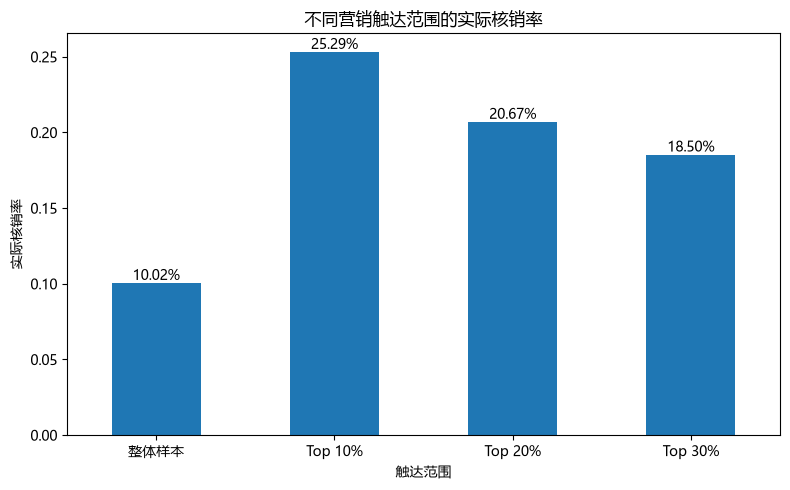

In [5]:
# 不同Top-K触达范围的实际核销率
baseline_rate = valid_model["label"].mean()

plot_data = pd.DataFrame({
    "触达范围": ["整体样本"] + topk_results["Top比例"].tolist(),
    "实际核销率": [baseline_rate] + topk_results["实际核销率"].tolist()
})

ax = plot_data.plot(
    x="触达范围",
    y="实际核销率",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("不同营销触达范围的实际核销率")
ax.set_xlabel("触达范围")
ax.set_ylabel("实际核销率")

for i, value in enumerate(plot_data["实际核销率"]):
    ax.text(
        i,
        value,
        f"{value:.2%}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "14_business_topk_redemption_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 2.2 Lift与核销用户捕获率分析

In [6]:
# Lift与核销用户捕获率
display_data = topk_results[
    ["Top比例", "Lift", "核销用户捕获率"]
].copy()

display_data["核销用户捕获率"] = (
    display_data["核销用户捕获率"] * 100
)

display_data.columns = [
    "触达范围",
    "Lift",
    "核销用户捕获率(%)"
]

display_data.round(2)

,触达范围,Lift,核销用户捕获率(%)
0,Top 10%,2.52,25.23
1,Top 20%,2.06,41.25
2,Top 30%,1.85,55.39


### 2.3 营销触达策略结论

模型筛选出的高潜样本具有明显更高的实际核销表现。其中，Top 10%样本的实际核销率达到25.29%，约为整体样本的2.52倍，适合在营销预算有限时进行重点触达。

扩大至Top 20%后，可覆盖41.25%的实际核销样本，同时保持2.06的Lift，在投放效率和用户覆盖之间取得较好的平衡。继续扩大至Top 30%虽然能够覆盖55.39%的实际核销样本，但Lift下降至1.85，边际投放效率有所降低。

因此，可根据营销目标采用分层触达策略：预算有限时优先触达Top 10%高潜样本；需要兼顾投放效率与覆盖范围时，可将Top 20%作为主要触达范围。

## 3. 优惠券策略分析

结合优惠券折扣力度、满减门槛及消费距离等因素，分析不同优惠券设计与使用场景的核销表现，为优惠券投放策略优化提供依据。

### 3.1 满减门槛与核销表现

In [7]:
# 满减优惠券不同门槛的核销表现
threshold_analysis = (
    valid_model[valid_model["is_manjian"] == 1]
    .groupby("discount_threshold")
    .agg(
        样本数=("label", "size"),
        核销数=("label", "sum"),
        核销率=("label", "mean")
    )
    .reset_index()
    .sort_values("discount_threshold")
)

# 仅保留样本数不少于100的门槛，避免极小样本干扰
threshold_analysis = threshold_analysis[
    threshold_analysis["样本数"] >= 100
]

threshold_analysis["核销率"] = (
    threshold_analysis["核销率"] * 100
)

threshold_analysis.round(2)

,discount_threshold,样本数,核销数,核销率
0,5.0,1566,299,19.09
1,10.0,10666,1556,14.59
2,20.0,59978,8443,14.08
3,30.0,74879,7994,10.68
4,50.0,15711,875,5.57
5,100.0,27945,1395,4.99
6,150.0,13195,113,0.86
7,200.0,7386,237,3.21
8,300.0,279,15,5.38


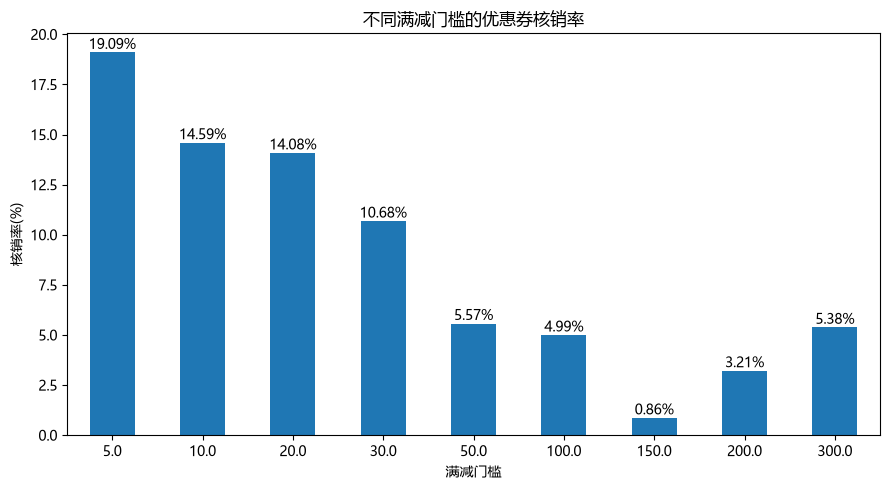

In [8]:
# 满减门槛与核销率
ax = threshold_analysis.plot(
    x="discount_threshold",
    y="核销率",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)

ax.set_title("不同满减门槛的优惠券核销率")
ax.set_xlabel("满减门槛")
ax.set_ylabel("核销率(%)")

for i, value in enumerate(threshold_analysis["核销率"]):
    ax.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "15_business_threshold_redemption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 3.1.1 满减门槛分析结论

不同满减门槛的优惠券核销表现存在明显差异。低门槛优惠券整体表现较好，其中满5、满10和满20的核销率分别达到19.09%、14.59%和14.08%；随着使用门槛提高，核销率总体呈下降趋势，满50和满100的核销率分别下降至5.57%和4.99%。

这说明较高的消费门槛可能增加用户使用优惠券的难度。在优惠券设计中，可优先考虑较低或适中的满减门槛，以降低用户核销门槛。需要注意的是，满200和满300等高门槛档位存在一定波动，因此不能简单认为核销率随门槛严格单调下降。

### 3.2 优惠力度与核销表现

In [9]:
# 将优惠力度划分为不同折扣区间
discount_analysis = valid_model.copy()

discount_analysis["discount_group"] = pd.cut(
    discount_analysis["discount_rate_value"],
    bins=[0, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=[
        "≤6折",
        "6-7折",
        "7-8折",
        "8-9折",
        "9-10折"
    ],
    include_lowest=True
)

discount_summary = (
    discount_analysis
    .groupby("discount_group", observed=True)
    .agg(
        样本数=("label", "size"),
        核销数=("label", "sum"),
        核销率=("label", "mean")
    )
    .reset_index()
)

discount_summary["核销率"] = discount_summary["核销率"] * 100

discount_summary.round(2)

,discount_group,样本数,核销数,核销率
0,≤6折,11448,453,3.96
1,6-7折,15062,647,4.30
2,7-8折,44995,5582,12.41
3,8-9折,101988,9469,9.28
4,9-10折,41855,5429,12.97


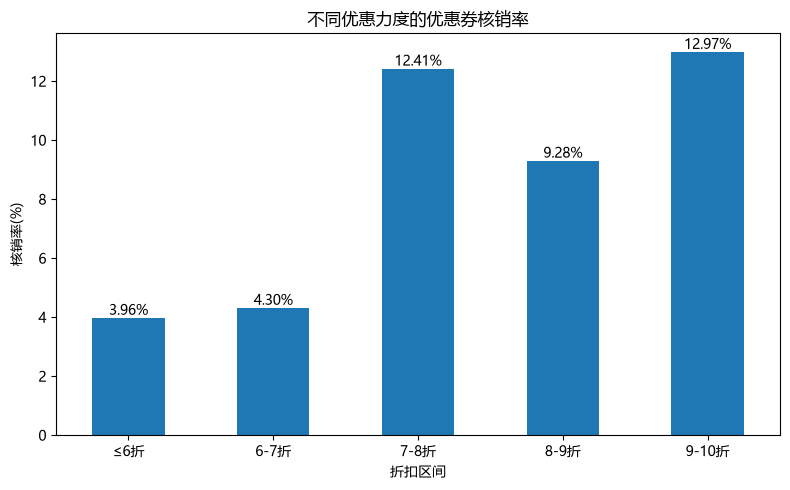

In [10]:
# 不同折扣区间的优惠券核销率
ax = discount_summary.plot(
    x="discount_group",
    y="核销率",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("不同优惠力度的优惠券核销率")
ax.set_xlabel("折扣区间")
ax.set_ylabel("核销率(%)")

for i, value in enumerate(discount_summary["核销率"]):
    ax.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "16_business_discount_redemption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 3.2.1 优惠力度分析结论

不同折扣区间的优惠券核销率并未呈现简单的单调关系。7-8折和9-10折优惠券的核销率较高，分别为12.41%和12.97%；而≤6折和6-7折优惠券的核销率仅为3.96%和4.30%。

这说明更大的折扣力度并不一定对应更高的核销率。优惠券的实际使用还可能受到满减门槛、用户消费需求及使用场景等因素影响。因此，在优惠券设计中不宜单纯依靠加大折扣力度提升核销效果，而应结合使用门槛等条件进行综合设计。

### 3.3 消费距离与核销表现

In [11]:
# 不同消费距离的优惠券核销表现
distance_summary = (
    valid_model[valid_model["distance_missing"] == 0]
    .groupby("distance_value")
    .agg(
        样本数=("label", "size"),
        核销数=("label", "sum"),
        核销率=("label", "mean")
    )
    .reset_index()
    .sort_values("distance_value")
)

distance_summary["核销率"] = distance_summary["核销率"] * 100

distance_summary.round(2)

,distance_value,样本数,核销数,核销率
0,0.0,94870,13068,13.77
1,1.0,32048,2375,7.41
2,2.0,13927,910,6.53
3,3.0,8977,547,6.09
4,4.0,6474,363,5.61
5,5.0,4647,240,5.16
6,6.0,3621,177,4.89
7,7.0,2794,117,4.19
8,8.0,2188,113,5.16
9,9.0,1936,119,6.15


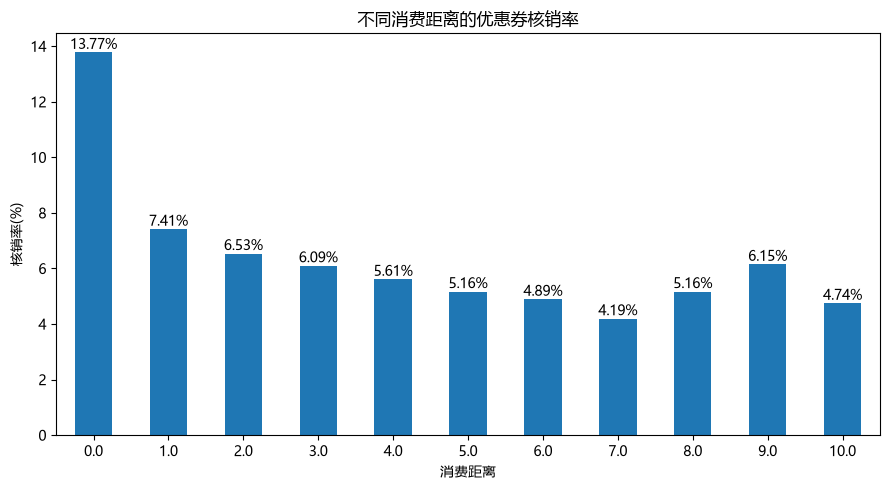

In [12]:
# 不同消费距离的优惠券核销率
ax = distance_summary.plot(
    x="distance_value",
    y="核销率",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)

ax.set_title("不同消费距离的优惠券核销率")
ax.set_xlabel("消费距离")
ax.set_ylabel("核销率(%)")

for i, value in enumerate(distance_summary["核销率"]):
    ax.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "17_business_distance_redemption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 3.3.1 消费距离分析结论

消费距离与优惠券核销表现存在明显关联。距离为0的样本核销率最高，达到13.77%；距离增加至1后，核销率下降至7.41%，随后整体呈下降趋势。

虽然距离8和9等区间存在一定波动，但总体来看，距离较近的消费场景具有更高的优惠券核销率。因此，在优惠券投放中可结合用户与商户的距离信息，对距离较近的用户进行优先触达，以提高营销资源的使用效率。

## 4. 用户分层与差异化营销策略

基于用户在预测时点之前已经成熟的历史领券行为，对用户进行活跃度分层，并比较不同用户群体的优惠券核销表现，为差异化营销策略制定提供依据。

### 4.1 用户历史活跃度分层

In [13]:
# 根据用户历史成熟领券次数划分活跃度
user_analysis = valid_model.copy()

user_analysis["user_activity_group"] = pd.cut(
    user_analysis["user_mature_coupon_count"],
    bins=[-1, 0, 3, float("inf")],
    labels=[
        "无历史记录",
        "低/中活跃用户",
        "高活跃用户"
    ]
)

activity_summary = (
    user_analysis
    .groupby("user_activity_group", observed=True)
    .agg(
        样本数=("label", "size"),
        核销数=("label", "sum"),
        核销率=("label", "mean")
    )
    .reset_index()
)

activity_summary["核销率"] = activity_summary["核销率"] * 100

activity_summary.round(2)

,user_activity_group,样本数,核销数,核销率
0,无历史记录,113815,9688,8.51
1,低/中活跃用户,78494,8512,10.84
2,高活跃用户,23039,3380,14.67


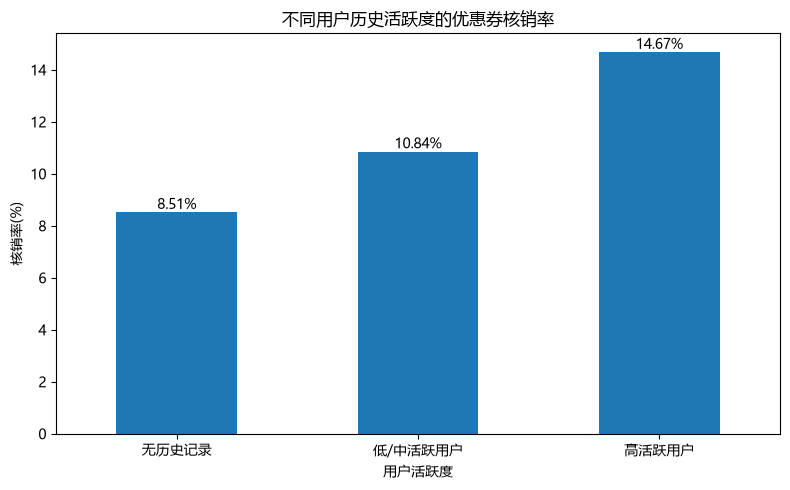

In [14]:
# 不同用户活跃度的优惠券核销率
ax = activity_summary.plot(
    x="user_activity_group",
    y="核销率",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("不同用户历史活跃度的优惠券核销率")
ax.set_xlabel("用户活跃度")
ax.set_ylabel("核销率(%)")

for i, value in enumerate(activity_summary["核销率"]):
    ax.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "18_business_user_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 4.1.1 用户历史活跃度分析结论

不同历史活跃度用户的优惠券核销表现存在明显差异。无历史记录用户的核销率为8.51%，低/中活跃用户提升至10.84%，高活跃用户进一步达到14.67%。

结果表明，用户过去的领券活跃程度与后续优惠券核销表现存在明显关联。因此，在营销资源有限的情况下，可将历史活跃度作为用户筛选的重要参考，对高活跃用户进行优先触达；对于无历史记录用户，则可采用较低成本的优惠券进行试探性触达，并根据后续行为进一步调整用户分层。

### 4.2 用户历史核销表现分层

In [15]:
# 根据用户历史成熟核销次数进行分层
redeem_analysis = valid_model.copy()

redeem_analysis["user_redeem_group"] = pd.cut(
    redeem_analysis["user_mature_redeem_count"],
    bins=[-1, 0, 2, float("inf")],
    labels=[
        "无历史核销",
        "历史核销1-2次",
        "历史核销3次及以上"
    ]
)

redeem_summary = (
    redeem_analysis
    .groupby("user_redeem_group", observed=True)
    .agg(
        样本数=("label", "size"),
        核销数=("label", "sum"),
        核销率=("label", "mean")
    )
    .reset_index()
)

redeem_summary["核销率"] = redeem_summary["核销率"] * 100

redeem_summary.round(2)

,user_redeem_group,样本数,核销数,核销率
0,无历史核销,197137,17021,8.63
1,历史核销1-2次,15012,3158,21.04
2,历史核销3次及以上,3199,1401,43.79


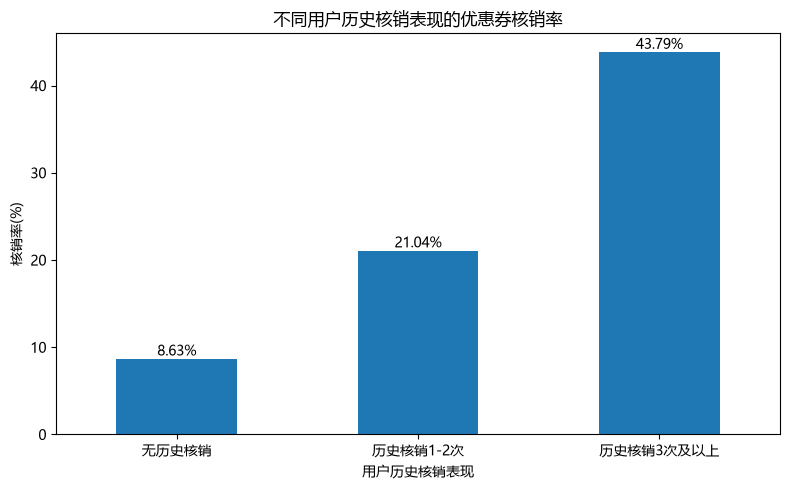

In [16]:
# 不同用户历史核销表现的当前核销率
ax = redeem_summary.plot(
    x="user_redeem_group",
    y="核销率",
    kind="bar",
    legend=False,
    figsize=(8, 5)
)

ax.set_title("不同用户历史核销表现的优惠券核销率")
ax.set_xlabel("用户历史核销表现")
ax.set_ylabel("核销率(%)")

for i, value in enumerate(redeem_summary["核销率"]):
    ax.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "19_business_user_redeem_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### 4.2.1 用户历史核销表现分析结论

用户历史核销表现与当前优惠券核销率存在明显关联。无历史核销用户的当前核销率为8.63%，历史核销1-2次用户提升至21.04%，历史核销3次及以上用户的核销率进一步达到43.79%。

相比单纯的历史领券活跃度，历史核销行为能够更加直接地反映用户对优惠券的实际使用意愿。因此，在精准营销中可将具有历史核销记录的用户作为重点营销对象，其中多次历史核销用户具有较高的再次核销潜力，可优先配置营销资源。

### 4.3 用户差异化营销策略

综合用户历史领券活跃度与历史核销表现，可以将用户划分为不同营销价值群体。对于具有多次历史核销记录的用户，其再次核销倾向较高，可作为重点维护和优先触达对象；对于具有一定历史领券或核销行为的用户，可通过适度优惠促进其进一步转化；对于缺乏历史行为记录的用户，则应控制营销成本，通过低成本优惠进行试探性触达。

因此，用户营销不宜采用统一投放策略，而应结合用户历史行为和模型预测概率进行差异化资源配置。在实际营销中，可优先参考模型识别出的Top高潜样本，并进一步结合用户历史核销表现确定触达优先级。

## 5. 综合精准营销策略

综合高潜样本识别、优惠券属性分析、消费距离及用户历史行为分析结果，从目标用户筛选、优惠券设计和营销资源配置三个方面形成精准营销策略。

### 5.1 目标用户筛选策略

模型排序结果显示，高潜样本具有明显更高的实际核销表现。Top 10%样本核销率达到25.29%，Lift为2.52；Top 20%样本核销率为20.67%，Lift为2.06，并能够覆盖41.25%的实际核销样本。

因此，在营销预算有限时，可优先选择模型预测概率排名前10%的高潜样本；若需要兼顾投放效率和用户覆盖，可将Top 20%作为主要营销范围。同时，可结合用户历史核销行为进一步确定触达优先级，对具有多次历史核销记录的用户进行重点维护。

### 5.2 优惠券设计策略

优惠券设计不应单纯追求更大的折扣力度。当前验证集结果显示，不同折扣区间的核销率呈现非单调关系，而较低和适中的满减门槛整体具有更好的核销表现。

因此，在优惠券设计中应综合考虑折扣力度与使用门槛。对于普通用户，可优先采用较低或适中的消费门槛，降低优惠券使用难度；对于高价值、高活跃用户，则可结合其历史消费行为设计更具针对性的优惠方案，避免通过无差别提高优惠力度增加营销成本。

### 5.3 场景化触达策略

消费距离与优惠券核销表现存在明显关联，距离较近的样本整体具有更高的核销率。因此，在营销触达过程中，可将用户与商户之间的距离作为重要的场景特征。

对于距离较近且模型预测核销概率较高的用户，可提高营销触达优先级；对于距离较远的用户，则应结合更强的消费需求或其他高价值特征进行筛选，减少低效率的广泛投放。

## 6. 营销策略汇总

将前述分析结果整理为可执行的营销策略，形成不同营销场景下的目标用户、触达方式及策略重点。

In [17]:
# 综合营销策略汇总
strategy_summary = pd.DataFrame({
    "营销场景": [
        "预算有限",
        "兼顾效率与覆盖",
        "高价值用户维护",
        "新用户/无历史用户",
        "优惠券设计",
        "距离场景"
    ],
    "目标群体": [
        "模型Top 10%高潜样本",
        "模型Top 20%高潜样本",
        "具有多次历史核销记录的用户",
        "无历史核销或历史行为较少的用户",
        "不同用户群体",
        "距离较近且预测概率较高的用户"
    ],
    "策略建议": [
        "优先集中营销资源，提高单位触达效率",
        "在投放效率与实际核销用户覆盖之间取得平衡",
        "重点维护并优先触达，提高用户持续核销价值",
        "采用低成本优惠进行试探性触达并积累行为数据",
        "优先采用较低或适中的使用门槛，避免单纯增加折扣力度",
        "结合距离和模型预测结果进行场景化精准触达"
    ]
})

strategy_summary

,营销场景,目标群体,策略建议
0,预算有限,模型Top 10%高潜样本,优先集中营销资源，提高单位触达效率
1,兼顾效率与覆盖,模型Top 20%高潜样本,在投放效率与实际核销用户覆盖之间取得平衡
2,高价值用户维护,具有多次历史核销记录的用户,重点维护并优先触达，提高用户持续核销价值
3,新用户/无历史用户,无历史核销或历史行为较少的用户,采用低成本优惠进行试探性触达并积累行为数据
4,优惠券设计,不同用户群体,优先采用较低或适中的使用门槛，避免单纯增加折扣力度
5,距离场景,距离较近且预测概率较高的用户,结合距离和模型预测结果进行场景化精准触达


In [18]:
# 保存综合营销策略
strategy_summary.to_csv(
    TABLE_DIR / "business_strategy_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("综合营销策略结果已保存")

综合营销策略结果已保存


## 7. 项目业务分析总结

本项目围绕O2O优惠券核销与精准营销问题，从用户行为、优惠券属性、消费场景和历史行为等多个维度开展分析，并结合机器学习模型识别高核销倾向样本。

业务分析结果显示，模型能够有效区分不同核销倾向的样本。Top 10%高潜样本的实际核销率达到25.29%，明显高于验证集10.02%的整体核销率；Top 20%样本能够覆盖41.25%的实际核销样本，在营销效率和覆盖范围之间具有较好的平衡。

优惠券策略方面，较低或适中的满减门槛整体具有更好的核销表现，而折扣力度与核销率并不存在简单的单调关系，说明优惠券设计需要综合考虑优惠力度与使用门槛。消费距离同样与核销表现存在明显关联，距离较近的消费场景整体表现更好。

用户行为方面，历史活跃程度和历史核销记录均能够有效区分用户后续核销表现。其中，历史核销3次及以上用户的当前核销率达到43.79%，表现出较高的再次核销倾向。

综合以上结果，实际营销中可采用“模型预测 + 用户历史行为 + 优惠券属性 + 消费场景”的多维精准营销方式，根据预算和覆盖目标选择Top 10%或Top 20%高潜样本，并针对不同用户群体制定差异化优惠券和触达策略，从而提高营销资源的使用效率。di